<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/PADS_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PADS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/PADS](https://github.com/Mishrakshitij/PADS)   
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter and is required for the pinned TensorFlow environment. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'PADS'
COMMIT = 'be7f8b9601ee9b219527fdc1429b47c4ae4e0b7a'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'accelerate>=1.2,<2', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy==1.26.4', 'pandas==2.2.3', 'tensorflow==2.15.1', 'simpletransformers==0.70.5', 'sentence-transformers<4']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: be7f8b9601ee9b219527fdc1429b47c4ae4e0b7a
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '1.26.4', 'pandas': '2.2.3', 'matplotlib': '3.10.7'}


In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"numpy>=1.23.5,<2",1.26.4,True
1,"tensorflow>=2.15,<2.16",2.15.1,True
2,"simpletransformers>=0.64,<0.71",0.70.5,True
3,"matplotlib>=3.7,<4",3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


In [ ]:
import os
os.environ["USE_TF"] = "0"  # Transformers uses PyTorch; the native policy imports TensorFlow separately.
import csv
import contextlib
import hashlib
import io
import json
import math
import runpy
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

REPO_ROOT, OUTPUT_DIR = Path(REPO_ROOT), Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO_ROOT / "src"))
torch.set_num_threads(2)
torch.manual_seed(42)
COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True).strip()
print({"repository": "Mishrakshitij/PADS", "commit": COMMIT, "numpy": np.__version__})

{'repository': 'Mishrakshitij/PADS', 'commit': 'be7f8b9601ee9b219527fdc1429b47c4ae4e0b7a', 'numpy': '1.26.4'}


Native dataset verification passed.


,rows
airline,237536
fastfood,181156
finance,157625
insurance,229982
media,487003
software,86224


,speaker,text,politeness_label_name
0,agent,Surely! No problem about that. Please give me ...,polite
1,agent,Surely! No problem about that. Please give me ...,polite
2,customer,"Or actually, if it's a window seat just keep i...",somewhat_polite
3,customer,"Or actually, if it's a window seat just keep i...",somewhat_polite


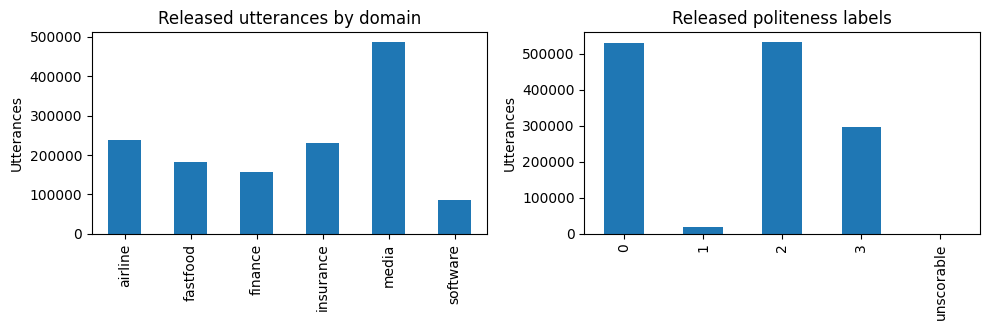

{'release_rows': 1379526, 'acoustic_rows': 1918, 'acoustic_subset_rows': 64, 'native_acoustic_lookup': 'passed'}


In [ ]:
from pads.environment import Environment
from pads.politeness import DistilBertPoliteness, EXPECTED_LABELS
from pads.reinforce import PolicyGradientREINFORCE
from pads.runner import run_episode, summarize, write_metrics
from pads.user import AcousticSampler, UserSimulator

verification_log = io.StringIO()
with contextlib.redirect_stdout(verification_log):
    runpy.run_path(str(REPO_ROOT / "scripts/verify_dataset.py"))["verify"](REPO_ROOT / "datasets")
(OUTPUT_DIR / "dataset_verification.txt").write_text(verification_log.getvalue())
print("Native dataset verification passed.")
domain_counts = Counter()
label_counts = Counter()
annotation_status = Counter()
word_lengths = []
preview = []
source_hashes = {}
for path in sorted((REPO_ROOT / "datasets").glob("*.part-*.csv")):
    source_hashes[path.name] = hashlib.sha256(path.read_bytes()).hexdigest()
    domain = path.name.split("_politeness")[0]
    with path.open(newline="", encoding="utf-8") as stream:
        for row in csv.DictReader(stream):
            domain_counts[domain] += 1
            label_counts[row["politeness_label"] or "unscorable"] += 1
            annotation_status[row["annotation_status"]] += 1
            if len(word_lengths) < 10000:
                word_lengths.append(len(row["text"].split()))
            if len(preview) < 4 and row["text"].strip():
                preview.append(row)
display(pd.DataFrame({"rows": domain_counts}))
display(pd.DataFrame(preview)[["speaker", "text", "politeness_label_name"]])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
pd.Series(domain_counts).plot.bar(ax=axes[0], title="Released utterances by domain")
pd.Series(label_counts).sort_index().plot.bar(ax=axes[1], title="Released politeness labels")
for axis in axes:
    axis.set_ylabel("Utterances")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_analysis.png", dpi=150)
plt.show()
acoustic = pd.read_csv(REPO_ROOT / "data/simulator/sample_from.csv")
acoustic_subset = acoustic.head(64)
acoustic_path = OUTPUT_DIR / "acoustic_subset.csv"
acoustic_subset.to_csv(acoustic_path, index=False)
pd.DataFrame(preview).to_csv(OUTPUT_DIR / "utterance_subset.csv", index=False)
sampler = AcousticSampler(acoustic_path)
row = acoustic_subset.iloc[0]
history = Counter({index: int(row[f"total_act{index}"]) for index in range(8)})
features, found = sampler.sample(int(row["myAction"]), history, np.random.default_rng(42))
assert found and features.shape == (8,) and np.isfinite(features).all()
print({"release_rows": sum(domain_counts.values()),
       "acoustic_rows": len(acoustic), "acoustic_subset_rows": len(acoustic_subset),
       "native_acoustic_lookup": "passed"})

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

classifier_dir = OUTPUT_DIR / "tiny_politeness"
tokenizer = AutoTokenizer.from_pretrained(str(DISTILBERT_MODEL))
classifier = AutoModelForSequenceClassification.from_pretrained(
    str(DISTILBERT_MODEL), num_labels=4, id2label=dict(enumerate(EXPECTED_LABELS)),
    label2id={label: index for index, label in enumerate(EXPECTED_LABELS)},
    ignore_mismatched_sizes=True)
classifier.save_pretrained(classifier_dir)
tokenizer.save_pretrained(classifier_dir)
del classifier
scorer = DistilBertPoliteness(classifier_dir)
scorer.model.args.use_multiprocessing = False
scorer.model.args.use_multiprocessing_for_evaluation = False
scorer.model.args.process_count = 1
scorer.model.args.silent = True
scorer.model.args.max_seq_length = 48
scorer.model.args.eval_batch_size = 4
scorer.model.args.cache_dir = str(OUTPUT_DIR / "classifier_cache")
scorer.model.args.no_cache = True
labels, logits = scorer.model.predict([row["text"] for row in preview])
assert len(labels) == 4 and np.asarray(logits).shape == (4, 4)
assert np.isfinite(logits).all() and all(int(label) in range(4) for label in labels)
classifier_predictions = [{"text": row["text"], "reference": row["politeness_label_name"],
                           "prediction": EXPECTED_LABELS[int(label)]}
                          for row, label in zip(preview, labels)]
display(pd.DataFrame(classifier_predictions))
reward_calls = {"count": 0}
def observed_scorer(user_text, bot_text):
    value = scorer(user_text, bot_text)
    reward_calls["count"] += 1
    assert math.isfinite(value)
    return value

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-DistilBertModel and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


python_environment/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
python_environment/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias u

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map: 100%|██████████| 4/4 [00:00<00:00, 231.29 examples/s]

,text,reference,prediction
0,Surely! No problem about that. Please give me ...,polite,somewhat_polite
1,Surely! No problem about that. Please give me ...,polite,somewhat_polite
2,"Or actually, if it's a window seat just keep i...",somewhat_polite,somewhat_polite
3,"Or actually, if it's a window seat just keep i...",somewhat_polite,somewhat_polite


In [ ]:
agent = PolicyGradientREINFORCE(hidden_dim=8, learning_rate=1e-3, seed=42)
with agent.graph.as_default():
    variables = agent.tf.trainable_variables()
before = agent.session.run(variables)
env = Environment(UserSimulator(clean_prob=1.0, seed=42, sampler=sampler), observed_scorer)
training_rows = []
for episode in range(1, 6):
    training_rows.append({"episode": episode, **run_episode(env, max_steps=5, agent=agent, training=True)})
updates = int(agent.session.run(agent.global_step))
assert updates == 5 and reward_calls["count"] > 0
assert all(math.isfinite(row["loss"]) for row in training_rows)
after = agent.session.run(variables)
assert any(not np.array_equal(initial, trained) for initial, trained in zip(before, after))
checkpoint = agent.save(OUTPUT_DIR / "policy")
write_metrics(OUTPUT_DIR / "training.csv", training_rows)
display(pd.DataFrame(training_rows))
print({"observed_optimizer_updates": updates, "native_politeness_reward_calls": reward_calls["count"]})
agent.close()

Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


PADS_source/src/pads/reinforce.py:52: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.nn.rnn_cell.LSTMCell(hidden_dim, state_is_tuple=True)


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

...

Map: 100%|██████████| 2/2 [00:00<00:00, 894.50 examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map: 100%|██████████| 2/2 [00:00<00:00, 922.84 examples/s]

,episode,reward,length,success,loss
0,1,25.0,5,0,-0.033756
1,2,40.0,5,1,1.427680
2,3,40.0,5,1,1.024511
3,4,25.0,5,0,-1.463842
4,5,25.0,5,0,-1.044442


{'observed_optimizer_updates': 5, 'native_politeness_reward_calls': 23}


PADS_source/src/pads/reinforce.py:52: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.nn.rnn_cell.LSTMCell(hidden_dim, state_is_tuple=True)


INFO:tensorflow:Restoring parameters from PADS_outputs/policy/policy-5


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map: 100%|██████████| 2/2 [00:00<00:00, 809.16 examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

...

Map: 100%|██████████| 2/2 [00:00<00:00, 857.03 examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map: 100%|██████████| 2/2 [00:00<00:00, 699.81 examples/s]

,episode,reward,length,success
0,1,35.0,4,1
1,2,35.0,4,1
2,3,25.0,5,0
3,4,25.0,5,0


,episodes,mean_reward,mean_length,success_rate
0,4,30.0,4.5,0.5


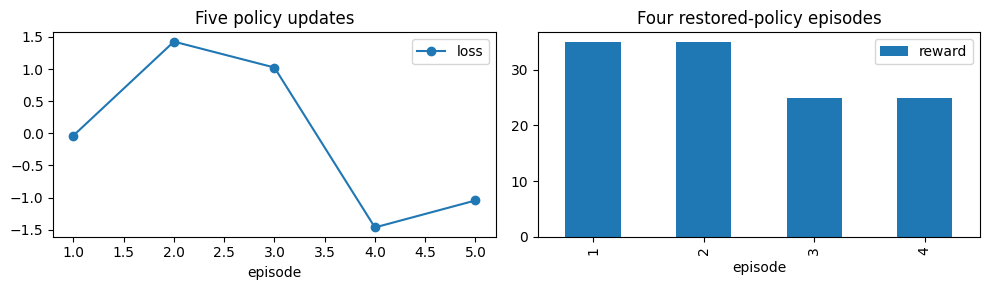

{'status': 'pass', 'native_policy_updates': 5, 'evaluation_episodes': 4, 'classifier_utterances': 4}


In [ ]:
restored = PolicyGradientREINFORCE(hidden_dim=8, learning_rate=1e-3, seed=100)
restored.restore(OUTPUT_DIR / "policy")
with restored.graph.as_default():
    restored_variables = restored.tf.trainable_variables()
reloaded = restored.session.run(restored_variables)
assert len(after) == len(reloaded)
assert all(np.array_equal(saved, loaded) for saved, loaded in zip(after, reloaded))
assert int(restored.session.run(restored.global_step)) == 5
eval_env = Environment(UserSimulator(clean_prob=1.0, seed=1000042, sampler=sampler), observed_scorer)
evaluation_rows = [{"episode": index + 1, **run_episode(eval_env, max_steps=5, agent=restored)}
                   for index in range(4)]
assert len(evaluation_rows) == 4
metrics = summarize(evaluation_rows)
assert all(math.isfinite(float(value)) for value in metrics.values())
restored.close()
write_metrics(OUTPUT_DIR / "evaluation.csv", evaluation_rows)
display(pd.DataFrame(evaluation_rows))
display(pd.DataFrame([metrics]))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
pd.DataFrame(training_rows).plot(x="episode", y="loss", marker="o", ax=axes[0], title="Five policy updates")
pd.DataFrame(evaluation_rows).plot.bar(x="episode", y="reward", ax=axes[1], title="Four restored-policy episodes")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_evaluation.png", dpi=150)
plt.show()
(OUTPUT_DIR / "classifier_predictions.json").write_text(json.dumps(classifier_predictions, indent=2))
result = {"project": "PADS", "repository": "https://github.com/Mishrakshitij/PADS.git",
          "commit": COMMIT, "status": "pass", "optimizer_updates": updates, "eval_samples": 4,
          "counts": {"released_utterances": sum(domain_counts.values()), "acoustic_subset": 64,
                     "training_episodes": 5, "evaluation": 4, "classifier_inference": 4},
          "model": {"trainable_policy": "native TensorFlow LSTM REINFORCE (hidden_dim=8)",
                    "reward_backbone": str(DISTILBERT_MODEL)},
          "metrics": metrics, "training": summarize(training_rows),
          "checkpoints": ["policy/" + Path(checkpoint).name, "tiny_politeness"],
          "checks": {"native_dataset_verification": True, "native_acoustic_lookup": True, "hf_load": True, "native_reward_adapter": True,
                     "training": True, "parameter_update": True, "save_restore_exact": True,
                     "four_episode_evaluation": True, "four_utterance_classifier_inference": True},
          "limitations": ["The LSTM policy, not the language model, is trained by the released PADS algorithm.",
                          "The tiny classifier has a newly initialized head and supplies test rewards, not validated politeness judgments.",
                          "Acoustic values are sampled but are not part of the released 13-dimensional policy state.",
                          "The simulator returns zero acoustic features when a history is absent from the small lookup subset.",
                          "Five updates and four episodes verify executability, not task mastery or paper-level performance."],
          "dataset_sha256": source_hashes}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print({"status": "pass", "native_policy_updates": updates, "evaluation_episodes": 4,
       "classifier_utterances": 4})

## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **four simulator episodes and four released utterances for classifier inference**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.